# Lab 1: Water Potability EDA

This notebook explores the `water_potability.csv` dataset from Kaggle and completes the Lab 1 exploratory data analysis workflow:

1. Describe the data.
2. Visualize the data.
3. Identify and fill missing values.
4. Identify and remove outliers.
5. Check categorical variables.
6. Analyze numerical variables, scale features, save the cleaned data, and test the pH/Solids hypothesis.


In [1]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True


## Dataset

The dataset is stored locally in `dataset/water_potability.csv`. The target variable is `Potability`, where `1` means potable water and `0` means not potable water.


In [2]:
INPUT_FILE_PATH = "dataset/water_potability.csv"
df = pd.read_csv(INPUT_FILE_PATH)
df.head()


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.8905,20791.3190,7.3002,368.5164,564.3087,10.3798,86.9910,2.9631,0
1,3.7161,129.4229,18630.0579,6.6352,NaN,592.8854,15.1800,56.3291,4.5007,0
2,8.0991,224.2363,19909.5417,9.2759,NaN,418.6062,16.8686,66.4201,3.0559,0
3,8.3168,214.3734,22018.4174,8.0593,356.8861,363.2665,18.4365,100.3417,4.6288,0
4,9.0922,181.1015,17978.9863,6.5466,310.1357,398.4108,11.5583,31.9980,4.0751,0


## Data Dictionary

- `ph`: Acidic or alkaline condition of water.
- `Hardness`: Concentration of calcium and magnesium salts.
- `Solids`: Total dissolved solids.
- `Chloramines`: Chloramine level used for disinfection.
- `Sulfate`: Sulfate concentration.
- `Conductivity`: Electrical conductivity of water.
- `Organic_carbon`: Total organic carbon.
- `Trihalomethanes`: Chemicals that may appear in chlorinated water.
- `Turbidity`: Clarity of water.
- `Potability`: Target variable, `1` for potable and `0` for not potable.


## Describe the Data


In [3]:
# Shape of the dataset
rows, columns = df.shape
print(f"Rows: {rows}")
print(f"Columns: {columns}")


Rows: 3276
Columns: 10


In [4]:
# Datatypes of the columns
df.dtypes


ph                 float64
Hardness           float64
Solids             float64
Chloramines        float64
Sulfate            float64
Conductivity       float64
Organic_carbon     float64
Trihalomethanes    float64
Turbidity          float64
Potability           int64
dtype: object

In [5]:
# Descriptive statistics
df.describe().T


,count,mean,std,min,25%,50%,75%,max
ph,2785.0000,7.0808,1.5943,0.0000,6.0931,7.0368,8.0621,14.0000
Hardness,3276.0000,196.3695,32.8798,47.4320,176.8505,196.9676,216.6675,323.1240
Solids,3276.0000,22014.0925,8768.5708,320.9426,15666.6903,20927.8336,27332.7621,61227.1960
Chloramines,3276.0000,7.1223,1.5831,0.3520,6.1274,7.1303,8.1149,13.1270
Sulfate,2495.0000,333.7758,41.4168,129.0000,307.6995,333.0735,359.9502,481.0306
Conductivity,3276.0000,426.2051,80.8241,181.4838,365.7344,421.8850,481.7923,753.3426
Organic_carbon,3276.0000,14.2850,3.3082,2.2000,12.0658,14.2183,16.5577,28.3000
Trihalomethanes,3114.0000,66.3963,16.1750,0.7380,55.8445,66.6225,77.3375,124.0000
Turbidity,3276.0000,3.9668,0.7804,1.4500,3.4397,3.9550,4.5003,6.7390
Potability,3276.0000,0.3901,0.4878,0.0000,0.0000,0.0000,1.0000,1.0000


In [6]:
# Check duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"Duplicate rows: {duplicate_rows}")


Duplicate rows: 0


## Missing Values


In [7]:
# Check if there are any null columns
missing = df.isna().sum().to_frame("missing_count")
missing["missing_percent"] = (missing["missing_count"] / len(df) * 100).round(2)
missing


,missing_count,missing_percent
ph,491,14.9900
Hardness,0,0.0000
Solids,0,0.0000
Chloramines,0,0.0000
Sulfate,781,23.8400
Conductivity,0,0.0000
Organic_carbon,0,0.0000
Trihalomethanes,162,4.9500
Turbidity,0,0.0000
Potability,0,0.0000


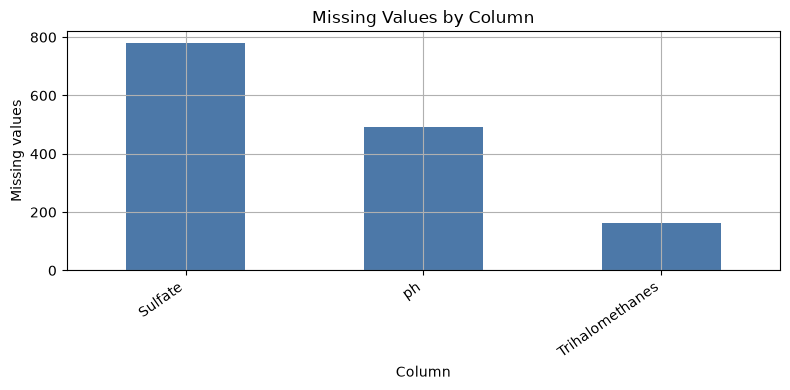

In [8]:
# Plot missing values
missing_counts = df.isna().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
missing_counts.plot(kind="bar", color="#4C78A8", ax=ax)
ax.set_title("Missing Values by Column")
ax.set_xlabel("Column")
ax.set_ylabel("Missing values")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


The columns with missing values are `Sulfate`, `ph`, and `Trihalomethanes`. The rest of the columns are complete.


## Analyze Columns With Missing Values

The next plots compare the distribution, mean, and median for each column with missing values. If mean and median are close and the distribution is not heavily skewed, mean imputation is a reasonable simple choice for this lab.


In [9]:
def plot_distribution_with_mean_median(dataframe, column):
    values = dataframe[column].dropna()
    mean_value = values.mean()
    median_value = values.median()

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(values, bins=35, color="#72B7B2", edgecolor="white")
    ax.axvline(mean_value, color="#E45756", linestyle="--", linewidth=2, label=f"Mean: {mean_value:.2f}")
    ax.axvline(median_value, color="#F58518", linestyle=":", linewidth=2, label=f"Median: {median_value:.2f}")
    ax.set_title(f"Distribution of {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Frequency")
    ax.legend()
    plt.tight_layout()
    plt.show()

    print(f"{column} mean: {mean_value:.4f}")
    print(f"{column} median: {median_value:.4f}")
    print(f"{column} skewness: {values.skew():.4f}")


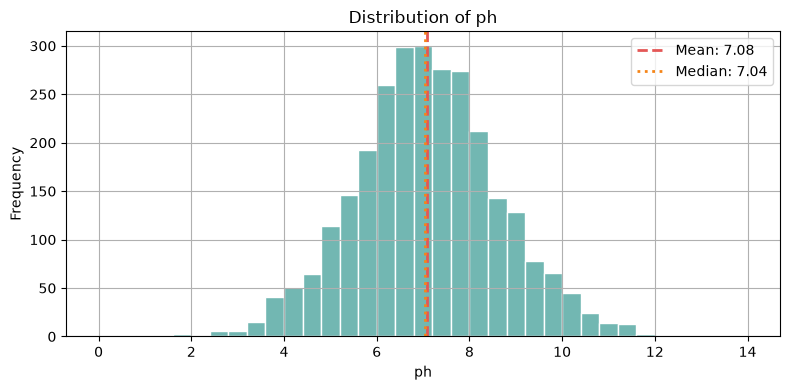

ph mean: 7.0808
ph median: 7.0368
ph skewness: 0.0256


In [10]:
# Analyze ph column
plot_distribution_with_mean_median(df, "ph")


For `ph`, the mean and median are close and skewness is low, so mean imputation is acceptable.


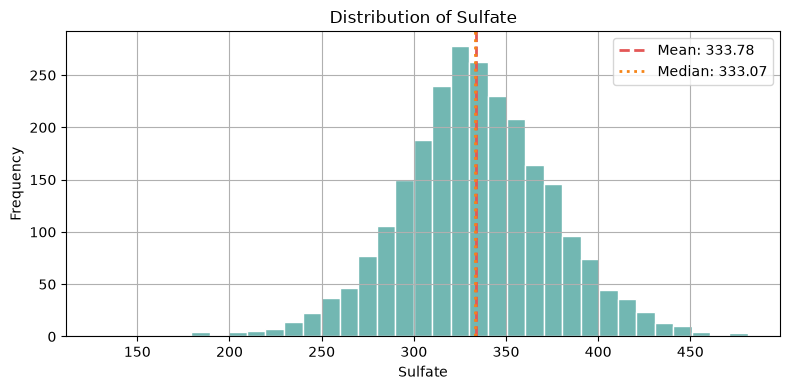

Sulfate mean: 333.7758
Sulfate median: 333.0735
Sulfate skewness: -0.0359


In [11]:
# Analyze Sulfate column
plot_distribution_with_mean_median(df, "Sulfate")


For `Sulfate`, the mean and median are close and skewness is low, so mean imputation is acceptable.


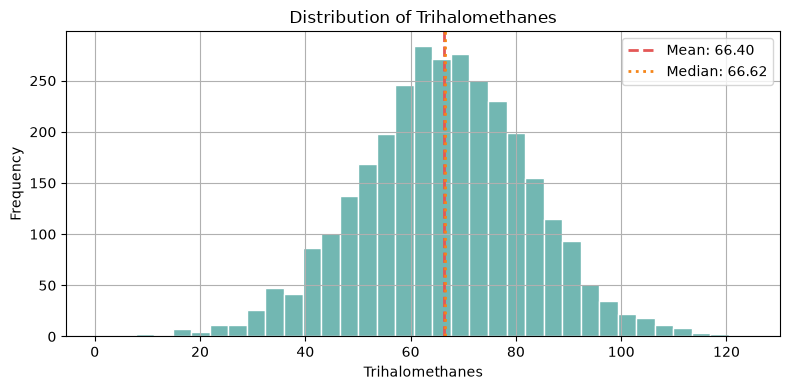

Trihalomethanes mean: 66.3963
Trihalomethanes median: 66.6225
Trihalomethanes skewness: -0.0830


In [12]:
# Analyze Trihalomethanes column
plot_distribution_with_mean_median(df, "Trihalomethanes")


For `Trihalomethanes`, the mean and median are close and skewness is low, so mean imputation is acceptable.


## Missing Value Imputation


In [13]:
# Impute missing values with the mean of each affected column
df_imputed = df.copy()
columns_to_impute = ["ph", "Sulfate", "Trihalomethanes"]
imputation_values = {}

for column in columns_to_impute:
    imputation_values[column] = df_imputed[column].mean()
    df_imputed[column] = df_imputed[column].fillna(imputation_values[column])

pd.DataFrame.from_dict(imputation_values, orient="index", columns=["mean_used_for_imputation"])


,mean_used_for_imputation
ph,7.0808
Sulfate,333.7758
Trihalomethanes,66.3963


In [14]:
# Confirm that missing values were filled
df_imputed.isna().sum()


ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64

## Identify Outliers

The lab asks us to identify and remove outliers. Here, outliers are detected with the IQR rule: values lower than `Q1 - 1.5 * IQR` or higher than `Q3 + 1.5 * IQR`.


In [15]:
feature_columns = [column for column in df_imputed.columns if column != "Potability"]

outlier_mask = pd.Series(False, index=df_imputed.index)
outlier_summary = []

for column in feature_columns:
    q1 = df_imputed[column].quantile(0.25)
    q3 = df_imputed[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    column_outliers = (df_imputed[column] < lower_bound) | (df_imputed[column] > upper_bound)
    outlier_mask = outlier_mask | column_outliers
    outlier_summary.append({
        "column": column,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": int(column_outliers.sum())
    })

outlier_summary = pd.DataFrame(outlier_summary).sort_values("outlier_count", ascending=False)
outlier_summary


,column,lower_bound,upper_bound,outlier_count
4,Sulfate,267.1580,400.3224,264
0,ph,3.8891,10.2586,142
1,Hardness,117.1252,276.3928,83
3,Chloramines,3.1462,11.0961,61
7,Trihalomethanes,26.6192,106.6950,54
2,Solids,-1832.4174,44831.8699,47
6,Organic_carbon,5.3280,23.2954,25
8,Turbidity,1.8488,6.0912,19
5,Conductivity,191.6476,655.8791,11


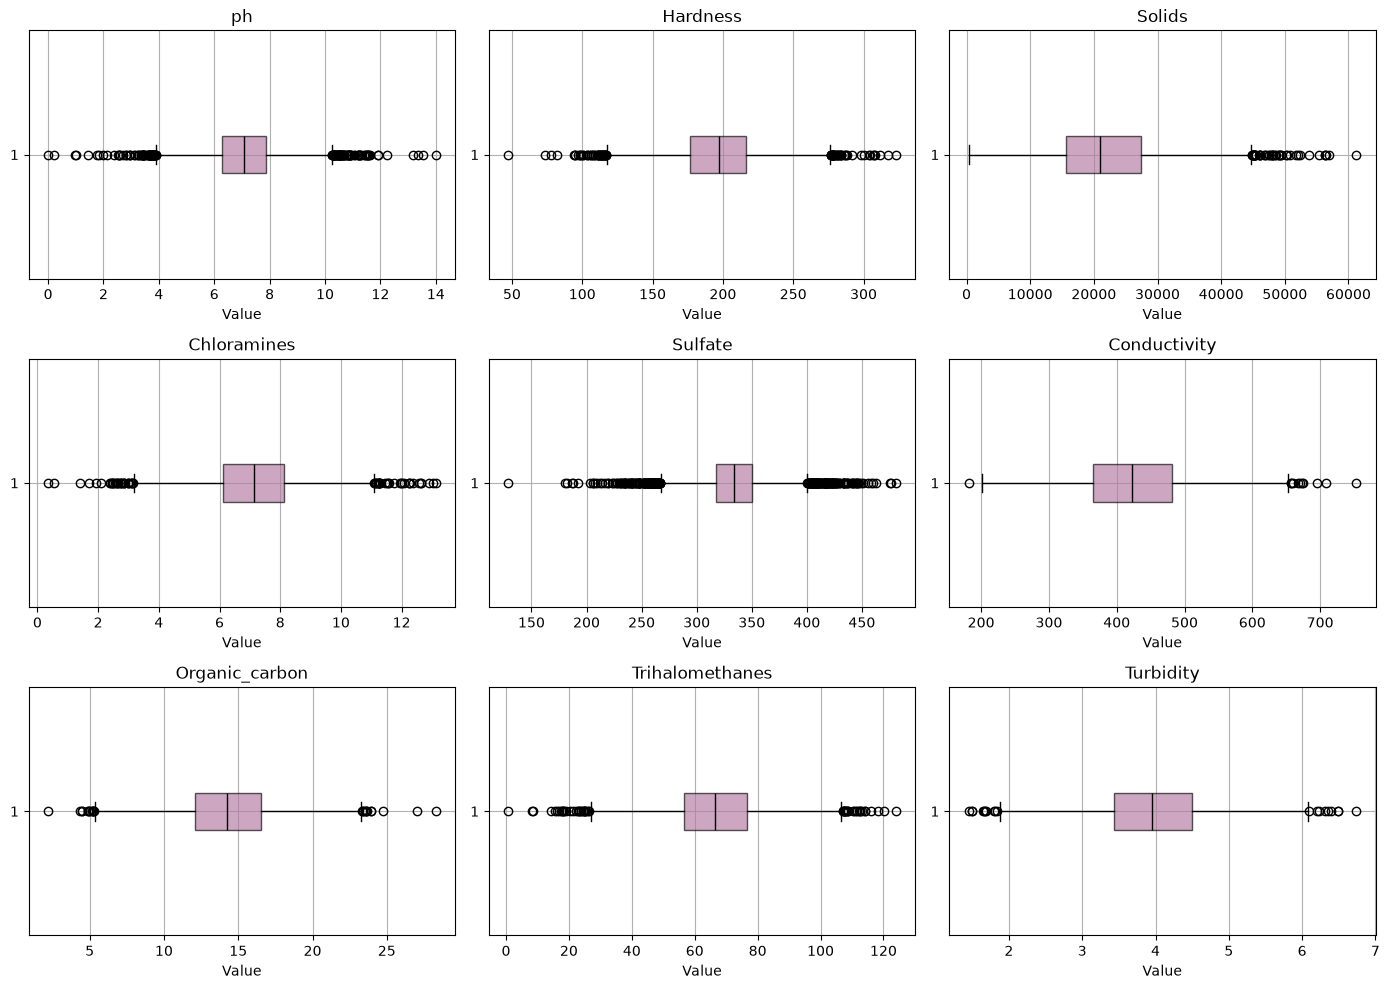

In [16]:
# Visualize outliers with boxplots
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.ravel()

for ax, column in zip(axes, feature_columns):
    ax.boxplot(df_imputed[column], orientation="horizontal", patch_artist=True,
               boxprops={"facecolor": "#B279A2", "alpha": 0.65},
               medianprops={"color": "black"})
    ax.set_title(column)
    ax.set_xlabel("Value")

plt.tight_layout()
plt.show()


In [17]:
# Remove rows that contain any IQR outlier in the feature columns
df_clean = df_imputed.loc[~outlier_mask].reset_index(drop=True)

print(f"Rows before outlier removal: {len(df_imputed)}")
print(f"Rows removed as outliers: {int(outlier_mask.sum())}")
print(f"Rows after outlier removal: {len(df_clean)}")


Rows before outlier removal: 3276
Rows removed as outliers: 610
Rows after outlier removal: 2666


## Correlation Between Variables


In [18]:
# Correlation matrix
correlation_matrix = df_clean.corr(numeric_only=True).round(3)
correlation_matrix


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
ph,1.0000,0.1310,-0.0870,-0.0630,0.0170,0.0020,0.0260,0.0090,-0.0430,-0.0060
Hardness,0.1310,1.0000,-0.0460,-0.0360,-0.0280,-0.0300,0.0120,-0.0070,-0.0220,-0.0010
Solids,-0.0870,-0.0460,1.0000,-0.0400,-0.1100,0.0070,0.0270,-0.0250,0.0230,0.0060
Chloramines,-0.0630,-0.0360,-0.0400,1.0000,0.0250,-0.0150,-0.0010,0.0170,-0.0050,0.0130
Sulfate,0.0170,-0.0280,-0.1100,0.0250,1.0000,-0.0060,-0.0080,-0.0220,-0.0170,-0.0040
Conductivity,0.0020,-0.0300,0.0070,-0.0150,-0.0060,1.0000,0.0070,-0.0010,0.0080,-0.0020
Organic_carbon,0.0260,0.0120,0.0270,-0.0010,-0.0080,0.0070,1.0000,-0.0000,-0.0170,-0.0270
Trihalomethanes,0.0090,-0.0070,-0.0250,0.0170,-0.0220,-0.0010,-0.0000,1.0000,-0.0240,0.0140
Turbidity,-0.0430,-0.0220,0.0230,-0.0050,-0.0170,0.0080,-0.0170,-0.0240,1.0000,0.0050
Potability,-0.0060,-0.0010,0.0060,0.0130,-0.0040,-0.0020,-0.0270,0.0140,0.0050,1.0000


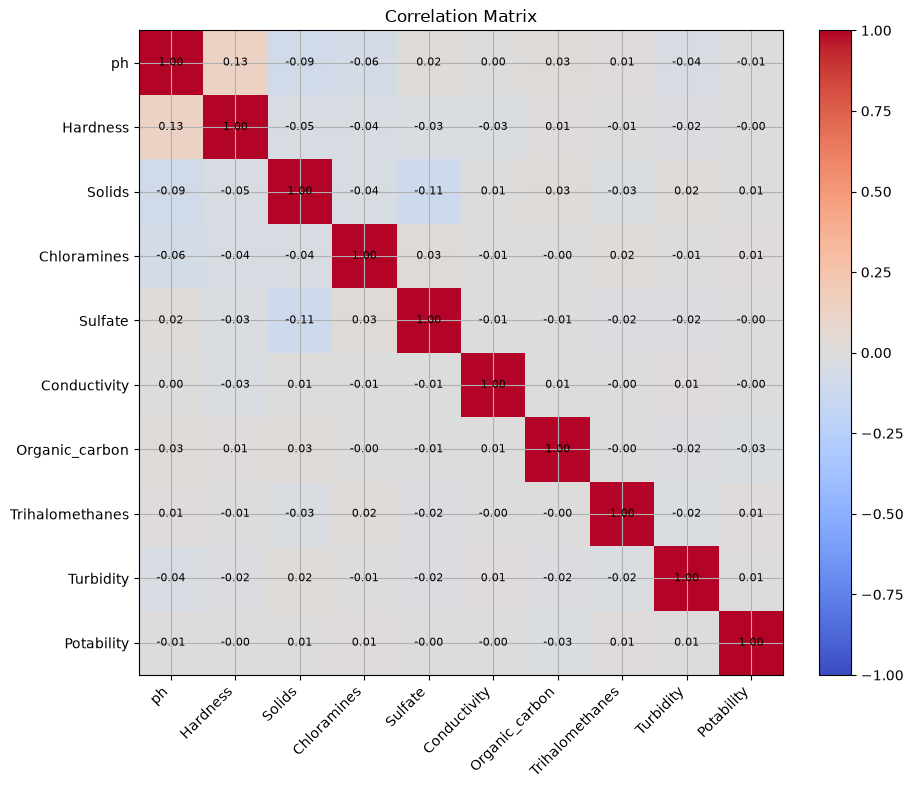

In [19]:
# Correlation heatmap using matplotlib
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(np.arange(len(correlation_matrix.columns)))
ax.set_yticks(np.arange(len(correlation_matrix.index)))
ax.set_xticklabels(correlation_matrix.columns, rotation=45, ha="right")
ax.set_yticklabels(correlation_matrix.index)

for i in range(len(correlation_matrix.index)):
    for j in range(len(correlation_matrix.columns)):
        ax.text(j, i, f"{correlation_matrix.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

ax.set_title("Correlation Matrix")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


There are no strong linear correlations with `Potability`. This suggests that simple one-variable rules will probably not separate potable and non-potable water very well.


## Categorical and Numerical Variables


In [20]:
# Identify categorical variables
categorical_columns = df_clean.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
print(f"Categorical columns: {categorical_columns}")


Categorical columns: []


There are no categorical variables in the dataset. All input features are numerical, and `Potability` is the numerical target label.


In [21]:
# Basic statistical analysis of numerical variables after cleaning
df_clean.describe().T


,count,mean,std,min,25%,50%,75%,max
ph,2666.0000,7.0735,1.2155,3.9025,6.3480,7.0808,7.7923,10.2528
Hardness,2666.0000,197.0520,28.3665,118.9886,179.0101,197.5615,215.7440,275.8865
Solids,2666.0000,21486.8290,7924.0927,320.9426,15596.7652,20583.1426,26742.1950,44652.3639
Chloramines,2666.0000,7.1112,1.4134,3.1950,6.1886,7.1142,8.0531,11.0865
Sulfate,2666.0000,333.7608,26.5056,267.2024,319.4816,333.7758,347.9212,400.2746
Conductivity,2666.0000,425.8112,79.9881,201.6197,365.6417,421.3203,481.4461,652.5376
Organic_carbon,2666.0000,14.3054,3.2171,5.3624,12.0829,14.2194,16.5755,23.2343
Trihalomethanes,2666.0000,66.4383,14.8986,27.5594,56.9160,66.3963,76.6288,106.3717
Turbidity,2666.0000,3.9617,0.7610,1.8726,3.4391,3.9458,4.4945,6.0838
Potability,2666.0000,0.3732,0.4838,0.0000,0.0000,0.0000,1.0000,1.0000


## Identify Skewness in the Data


In [22]:
# Identify skewness in the feature columns
skewness = df_clean[feature_columns].skew().to_frame("Skew")
skewness["Abs_Skew"] = skewness["Skew"].abs()
skewness.sort_values("Abs_Skew", ascending=False)


,Skew,Abs_Skew
Solids,0.3733,0.3733
Conductivity,0.2032,0.2032
ph,0.0465,0.0465
Sulfate,0.0367,0.0367
Trihalomethanes,-0.0241,0.0241
Hardness,-0.0217,0.0217
Chloramines,-0.0167,0.0167
Organic_carbon,0.0156,0.0156
Turbidity,-0.0142,0.0142


In [23]:
# Showing the skewed columns with absolute skewness above 1
skewed_columns = skewness[skewness["Abs_Skew"] > 1].sort_values("Abs_Skew", ascending=False)
print(f"Number of skewed columns: {len(skewed_columns)}")
skewed_columns[["Skew"]]


Number of skewed columns: 0


,Skew


No feature has absolute skewness above 1 after cleaning. `Solids` remains the most skewed feature, but it is still below the usual high-skew threshold.


## Distribution of Potability


In [24]:
# Distribution of Potability before outlier removal
df_imputed["Potability"].value_counts()


Potability
0    1998
1    1278
Name: count, dtype: int64

In [25]:
# Distribution of Potability after outlier removal
potability_counts = df_clean["Potability"].value_counts().sort_index()
potability_percent = (potability_counts / potability_counts.sum() * 100).round(2)
pd.DataFrame({"count": potability_counts, "percent": potability_percent})


,count,percent
Potability,,
0,1671,62.6800
1,995,37.3200


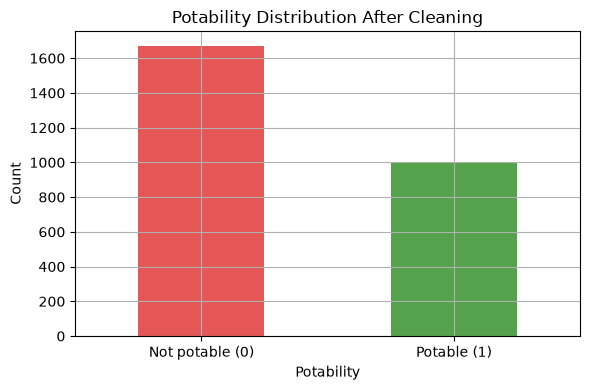

In [26]:
fig, ax = plt.subplots(figsize=(6, 4))
potability_counts.plot(kind="bar", color=["#E45756", "#54A24B"], ax=ax)
ax.set_title("Potability Distribution After Cleaning")
ax.set_xlabel("Potability")
ax.set_ylabel("Count")
ax.set_xticklabels(["Not potable (0)", "Potable (1)"], rotation=0)
plt.tight_layout()
plt.show()


The target is moderately imbalanced, with more non-potable samples than potable samples.


## Feature Transformation

The numerical feature columns are standardized with z-score scaling. The target column `Potability` is not scaled.


In [27]:
# Feature transformation: scale numeric feature columns only
feature_means = df_clean[feature_columns].mean()
feature_stds = df_clean[feature_columns].std(ddof=0)

df_scaled = df_clean.copy()
df_scaled[feature_columns] = (df_scaled[feature_columns] - feature_means) / feature_stds

df_scaled.head()


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,0.0060,0.2764,-0.0878,0.1338,1.3115,1.7318,-1.2205,1.3798,-1.3124,0
1,0.8439,0.9585,-0.1991,1.5318,0.0006,-0.0901,0.7969,-0.0012,-1.1904,0
2,1.0230,0.6107,0.0671,0.6709,0.8726,-0.7821,1.2844,2.2760,0.8768,0
3,1.6610,-0.5624,-0.4428,-0.3995,-0.8915,-0.3426,-0.8541,-2.3121,0.1491,0
4,-1.2256,-0.3081,0.9166,0.3069,-0.2673,-1.8174,-1.8361,-0.7734,-1.8427,0


In [28]:
# Confirm scaled feature means are close to 0 and standard deviations are close to 1
scaled_check = pd.DataFrame({
    "mean": df_scaled[feature_columns].mean().round(6),
    "std": df_scaled[feature_columns].std(ddof=0).round(6)
})
scaled_check


,mean,std
ph,-0.0000,1.0000
Hardness,0.0000,1.0000
Solids,0.0000,1.0000
Chloramines,0.0000,1.0000
Sulfate,-0.0000,1.0000
Conductivity,-0.0000,1.0000
Organic_carbon,0.0000,1.0000
Trihalomethanes,-0.0000,1.0000
Turbidity,-0.0000,1.0000


## Save the Cleaned Data


In [29]:
OUTPUT_FILE_PATH = "dataset/water_potability_cleaned.csv"
df_scaled.to_csv(OUTPUT_FILE_PATH, index=False)
print(f"Saved cleaned data to: {OUTPUT_FILE_PATH}")


Saved cleaned data to: dataset/water_potability_cleaned.csv


## Hypothesis Testing

Original lab hypothesis:

- Null: Increase in pH is associated with increase in Solids.
- Alternate: No relation between pH and Solids.

Because both `ph` and `Solids` are continuous variables, a correlation test is more appropriate than a two-sample t-test. I use Pearson correlation on the cleaned data. The conventional statistical setup is:

- H0: There is no linear relationship between `ph` and `Solids`.
- H1: There is a linear relationship between `ph` and `Solids`.


In [30]:
pearson_r, p_value = stats.pearsonr(df_clean["ph"], df_clean["Solids"])

hypothesis_result = pd.DataFrame({
    "test": ["Pearson correlation"],
    "statistic_r": [pearson_r],
    "p_value": [p_value],
    "alpha": [0.05]
})
hypothesis_result


,test,statistic_r,p_value,alpha
0,Pearson correlation,-0.0870,0.0000,0.0500


The p-value is below 0.05, so we reject the conventional null hypothesis of no linear relationship. However, the correlation coefficient is very small and negative. That means the relationship is statistically detectable in this dataset but practically weak, and the data does not support a meaningful positive association between pH and Solids.


## Next Step in Analyzing the Data

A useful next step is to build classification models that predict `Potability` from the water-quality features. Because the target is moderately imbalanced, model evaluation should include recall, precision, F1-score, and ROC-AUC, not only accuracy. Cross-validation should be used to compare models such as logistic regression, decision trees, random forests, and gradient boosting.


## Quality of Data

The dataset contains 3,276 rows and 10 columns, with no duplicate rows. Three columns have missing values: `Sulfate`, `ph`, and `Trihalomethanes`. All variables are numeric, so no categorical encoding is needed. The dataset has moderate target imbalance and several IQR outliers, so imputation, outlier handling, and feature scaling are important preprocessing steps.


## Key Findings

- `Sulfate` has the most missing values, followed by `ph` and `Trihalomethanes`.
- Mean imputation is reasonable for the missing columns because mean and median are close and skewness is low.
- The target has more non-potable observations than potable observations.
- No feature has a strong linear correlation with `Potability`.
- The pH/Solids relationship is statistically significant but very weak and negative after cleaning.
